# House Price Prediction
This project aims to predict house prices based on property features such as size, number of rooms, and amenities. The dataset was obtained from Kaggle's Housing Prices Dataset, containing 545 houses and 13 features. I will explore the data, preprocess it, engineer new features, and build regression models to estimate house prices.

## 1. Imports and Data Loading

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, cross_validate
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.base import clone

from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
# Load data from a CSV file
df = pd.read_csv('Housing.csv')

# Display the first few rows and info about the dataset
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


## 2. Data Exploration
I begin by examining the structure of the dataset which includes its size, data types, and basic statistics to understand what I am working with before any preprocessing.

In [3]:
# Display info about the dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   price             545 non-null    int64
 1   area              545 non-null    int64
 2   bedrooms          545 non-null    int64
 3   bathrooms         545 non-null    int64
 4   stories           545 non-null    int64
 5   mainroad          545 non-null    str  
 6   guestroom         545 non-null    str  
 7   basement          545 non-null    str  
 8   hotwaterheating   545 non-null    str  
 9   airconditioning   545 non-null    str  
 10  parking           545 non-null    int64
 11  prefarea          545 non-null    str  
 12  furnishingstatus  545 non-null    str  
dtypes: int64(6), str(7)
memory usage: 55.5 KB


In [4]:
# Display summary statistics for the target variable
df["price"].describe()

count    5.450000e+02
mean     4.766729e+06
std      1.870440e+06
min      1.750000e+06
25%      3.430000e+06
50%      4.340000e+06
75%      5.740000e+06
max      1.330000e+07
Name: price, dtype: float64

The mean house price is approximately $4.77 million, with a minimum of $1.75M and a maximum of $13.3M. The distribution is right-skewed, meaning a small number of very expensive houses pull the average up.

## 3. Preprocessing

The dataset has no missing values. To keep the workflow robust to missing data without leaking test-set statistics into training, imputation is done inside the modeling pipeline (Section 6): numerical columns are filled with the training-set median and categorical columns with the training-set most frequent value.

In [5]:
# Check for missing values
print(df.isnull().sum())

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64


## 4. Exploratory Data Analysis
I visualize the distributions and relationships between features and price to identify which variables are most influential.

### 4.1 Distribution of House Prices

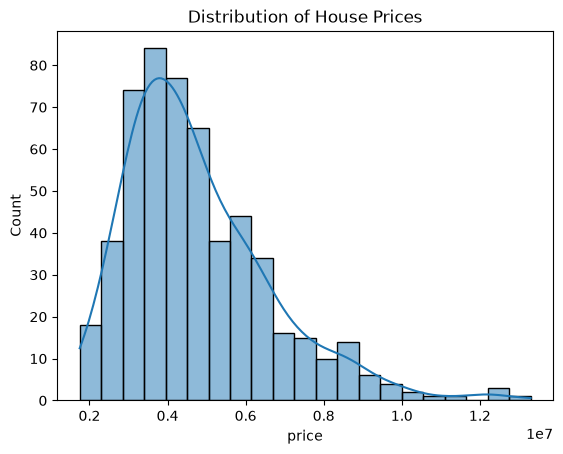

In [6]:
# Plot a histogram of the target variable (house prices)
sns.histplot(x=df["price"], kde=True)
plt.title("Distribution of House Prices")
plt.show()

The price distribution is right-skewed, with most houses priced between $2M and $7M. A small number of high-value properties extend the tail to the right.

### 4.2 Area vs Price

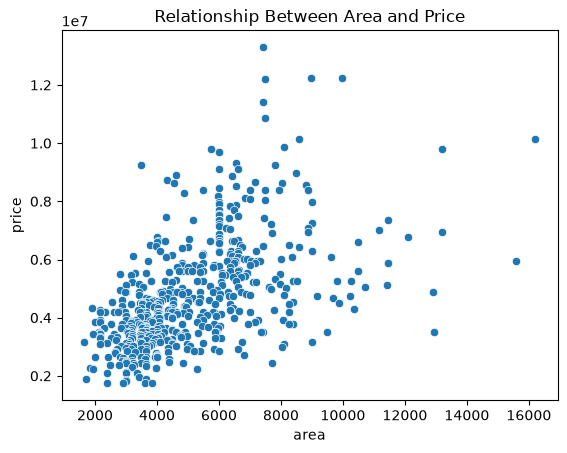

In [7]:
# Plot a scatter plot to visualize the relationship between area and price
sns.scatterplot(x="area", y="price", data=df)
plt.title("Relationship Between Area and Price")
plt.show()

There is a clear positive relationship between area and price, larger houses tend to cost more. However, the spread widens at higher areas, suggesting other features also play a role.

### 4.3 Feature Correlation Heatmap

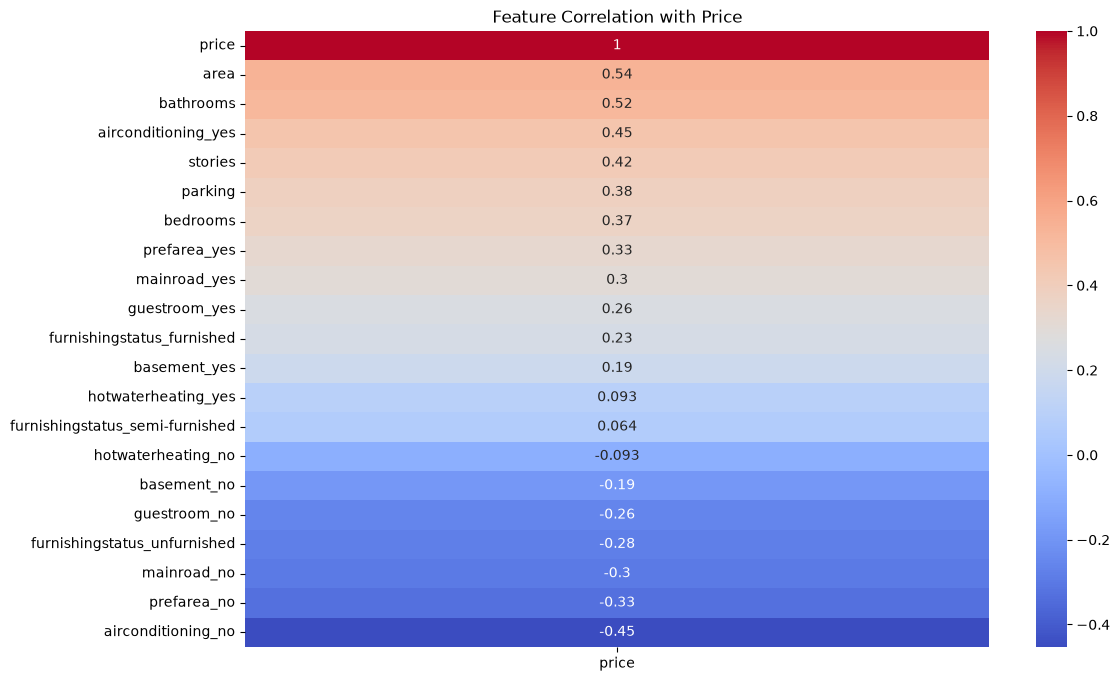

In [8]:
# Plot a heatmap to visualize correlations between features and price
df_encoded = pd.get_dummies(df)
plt.figure(figsize=(12,8))
sns.heatmap(df_encoded.corr()[["price"]].sort_values("price", ascending=False), annot=True, cmap="coolwarm")
plt.title("Feature Correlation with Price")
plt.show()

Area (0.54) and bathrooms (0.52) show the strongest correlations with price among numerical features. No single feature dominates, suggesting that a multi-feature model is necessary for accurate predictions.

## 5. Feature Engineering
I create two new features to capture additional information. `total_rooms` combines bedrooms and bathrooms, as overall room count may be more predictive than either alone. `area_per_room` captures how spacious the house is relative to its size.

In [9]:
# Feature engineering: create new features based on existing ones
df["total_rooms"] = df["bedrooms"] + df["bathrooms"]
df["area_per_room"] = df["area"] / (df["total_rooms"] + 1)

## 6. Model Setup
I split the data 80/20 into training and test sets. Missing values are imputed, numerical features are standardized so that large values like area don't dominate smaller ones like bedrooms, and categorical features are one-hot encoded to convert them into a numerical format the model can use. All of these steps are fit on the training data only, inside a Pipeline that chains preprocessing and modeling together.

In [10]:
# Define features and target
X = df.drop("price", axis=1)
y = df["price"]

# Train-test split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Identify numeric and categorical features
numeric_features = X.select_dtypes(include="number").columns
categorical_features = X.select_dtypes(exclude="number").columns

# Define the preprocessor (imputation happens here so it is learned from training data only)
preprocessor = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]), numeric_features),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(drop="first", handle_unknown="ignore"))
    ]), categorical_features)
])

## 7. Modeling & Evaluation
Before training real models, I measure a naive baseline that always predicts the mean training price. Any useful model must beat it. I then start with Linear Regression, which is simple, interpretable, and works well when relationships between features and the target are approximately linear.

### 7.1 Baseline (Mean Price)

In [11]:
# Baseline: always predict the mean training price
baseline = DummyRegressor(strategy="mean").fit(X_train, y_train)
y_pred_base = baseline.predict(X_test)

# Mean price for reference
mean_price = y_test.mean()

print(f"Baseline MAE as % of mean price: {mean_absolute_error(y_test, y_pred_base) / mean_price * 100:.1f}%")
print(f"Baseline RMSE as % of mean price: {np.sqrt(mean_squared_error(y_test, y_pred_base)) / mean_price * 100:.1f}%")

Baseline MAE as % of mean price: 34.9%
Baseline RMSE as % of mean price: 45.3%


### 7.2 Linear Regression

In [12]:
# Create a pipeline that combines the preprocessor with a linear regression model
model = Pipeline([
    ("preprocessor", clone(preprocessor)),
    ("regressor", LinearRegression())
])

# Train the model
model.fit(X_train, y_train)
# Make predictions
y_pred = model.predict(X_test)

# Print evaluation metrics
print("MAE:", mean_absolute_error(y_test, y_pred))
print(f"MAE as % of mean price: {mean_absolute_error(y_test, y_pred) / mean_price * 100:.1f}%")
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print(f"RMSE as % of mean price: {np.sqrt(mean_squared_error(y_test, y_pred)) / mean_price * 100:.1f}%")
print("R2:", r2_score(y_test, y_pred))

MAE: 966254.1084395876
MAE as % of mean price: 19.3%
RMSE: 1313237.0101228138
RMSE as % of mean price: 26.2%
R2: 0.6588055243671118


The Linear Regression model achieves an R² of 0.66, meaning it explains 66% of the variance in house prices. The MAE is about 19% of the mean price, compared to about 35% for the mean-price baseline, so the model cuts the average error by roughly 45%.

### 7.3 Predicted vs Actual -- Linear Regression

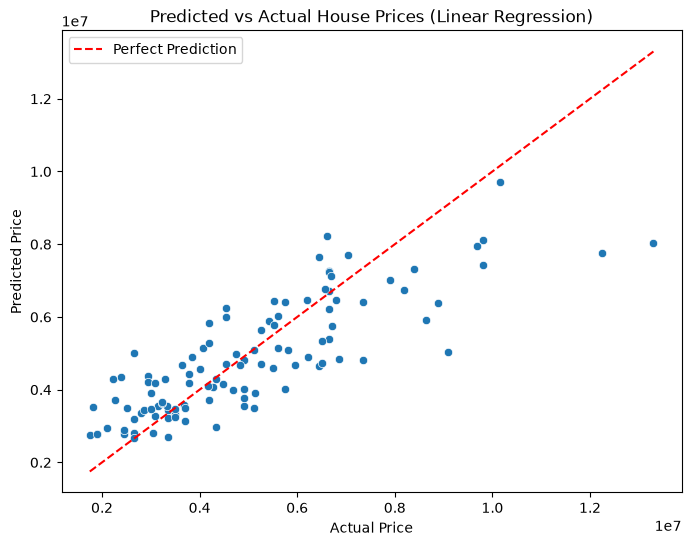

In [13]:
# Plot predicted vs actual prices
plt.figure(figsize=(8, 6))
pred_actual = pd.DataFrame({"Actual": y_test, "Predicted": y_pred})
sns.scatterplot(data=pred_actual, x="Actual", y="Predicted")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label="Perfect Prediction")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Predicted vs Actual House Prices (Linear Regression)")
plt.legend()
plt.show()

Points close to the red dashed line indicate accurate predictions. The model performs well in the low to mid-price range but shows more spread at higher prices, suggesting it underestimates expensive houses.

### 7.4 Random Forest Regression

In [14]:
# Create a pipeline that combines the preprocessor with a Random Forest Regressor
rf_model = Pipeline([
    ("preprocessor", clone(preprocessor)),
    ("regressor", RandomForestRegressor(
        n_estimators=200,
        max_depth=10,
        min_samples_leaf=2,
        max_features='sqrt',
        random_state=42
    ))
])

# Train the model
rf_model.fit(X_train, y_train)

# Make predictions
y_pred_rf = rf_model.predict(X_test)

# Print evaluation metrics for Random Forest
print("RF MAE:", mean_absolute_error(y_test, y_pred_rf))
print(f"RF MAE as % of mean price: {mean_absolute_error(y_test, y_pred_rf) / mean_price * 100:.1f}%")
print("RF RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))
print(f"RF RMSE as % of mean price: {np.sqrt(mean_squared_error(y_test, y_pred_rf)) / mean_price * 100:.1f}%")
print("RF R2:", r2_score(y_test, y_pred_rf))

RF MAE: 1039480.6301919452
RF MAE as % of mean price: 20.8%
RF RMSE: 1399642.4813620534
RF RMSE as % of mean price: 28.0%
RF R2: 0.6124301414063473


On this particular test split, the Random Forest underperforms Linear Regression. With only 545 rows, however, a single 109-row test set is noisy, so I check whether this result holds up with cross-validation below.

### 7.5 Predicted vs Actual -- Random Forest

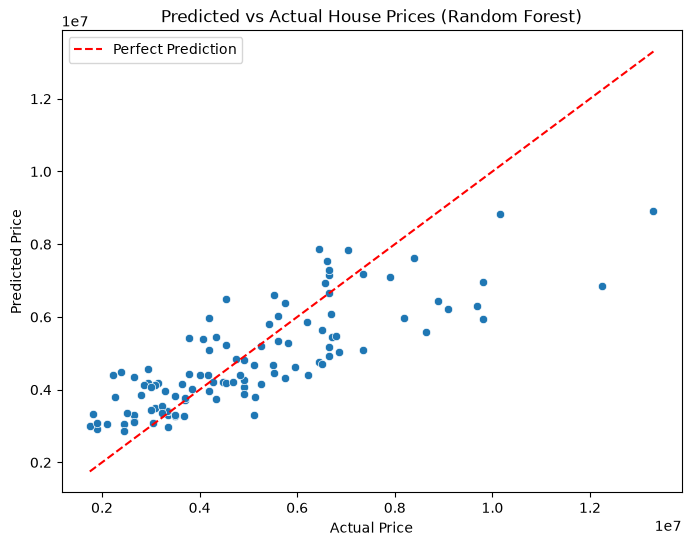

In [15]:
# Plot predicted vs actual prices for Random Forest
plt.figure(figsize=(8, 6))
pred_actual_rf = pd.DataFrame({"Actual": y_test, "Predicted": y_pred_rf})
sns.scatterplot(data=pred_actual_rf, x="Actual", y="Predicted")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label="Perfect Prediction")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Predicted vs Actual House Prices (Random Forest)")
plt.legend()
plt.show()

### 7.6 Cross-Validation
A single train/test split can make one model look better or worse by chance. To get a more reliable comparison, I run 5-fold cross-validation on the full dataset for both models. Each fold refits the whole pipeline, so preprocessing is still learned from training folds only.

In [16]:
# 5-fold cross-validation for both models
cv = KFold(n_splits=5, shuffle=True, random_state=42)
scoring = {"r2": "r2", "mae": "neg_mean_absolute_error", "rmse": "neg_root_mean_squared_error"}

cv_results = []
for name, pipe in [("Linear Regression", model), ("Random Forest", rf_model)]:
    scores = cross_validate(pipe, X, y, cv=cv, scoring=scoring)
    cv_results.append({
        "Model": name,
        "R2 (mean)": scores["test_r2"].mean(),
        "R2 (std)": scores["test_r2"].std(),
        "MAE % of mean price": -scores["test_mae"].mean() / y.mean() * 100,
        "RMSE % of mean price": -scores["test_rmse"].mean() / y.mean() * 100,
    })

pd.DataFrame(cv_results).set_index("Model").round(3)

,R2 (mean),R2 (std),MAE % of mean price,RMSE % of mean price
Model,,,,
Linear Regression,0.636,0.075,16.743,22.613
Random Forest,0.641,0.040,16.578,22.808


Under cross-validation the two models are essentially tied (R² ≈ 0.64 for both), and the gap between them is much smaller than the fold-to-fold variation. The single-split advantage of Linear Regression is therefore not a reliable difference. Random Forest is slightly more stable across folds (lower standard deviation), while Linear Regression matches its accuracy and is far easier to interpret.

### 7.7 Feature Importance (Linear Regression Coefficients)
Because numerical features are standardized, the size of each Linear Regression coefficient shows how strongly that feature moves the predicted price. For numerical features, the coefficient is the price change for a one-standard-deviation increase; for categorical features, it is the price difference relative to the dropped reference category.

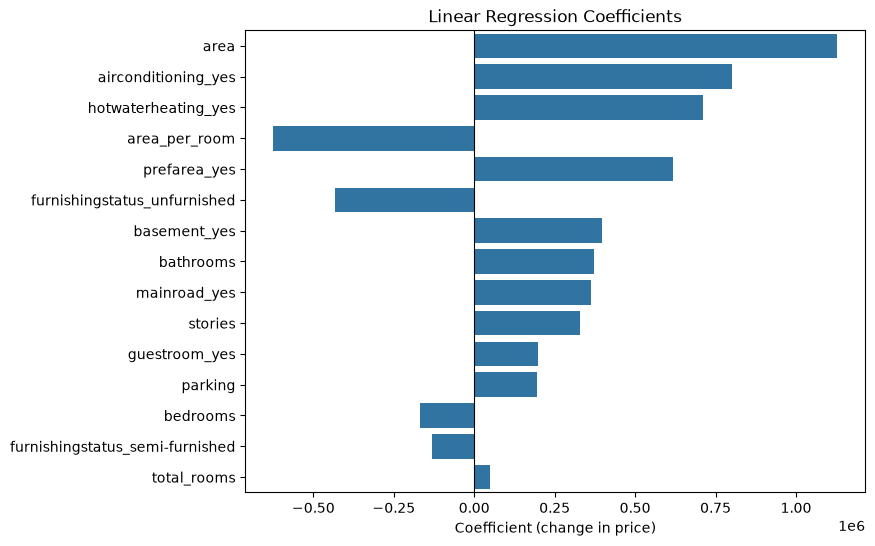

In [17]:
# Extract and plot the Linear Regression coefficients
feature_names = model.named_steps["preprocessor"].get_feature_names_out()
coefs = pd.Series(model.named_steps["regressor"].coef_, index=feature_names)
coefs.index = coefs.index.str.replace("num__", "").str.replace("cat__", "")
coefs = coefs.sort_values(key=abs, ascending=False)

plt.figure(figsize=(8, 6))
sns.barplot(x=coefs.values, y=coefs.index, orient="h")
plt.axvline(0, color="black", linewidth=0.8)
plt.xlabel("Coefficient (change in price)")
plt.ylabel("")
plt.title("Linear Regression Coefficients")
plt.show()

Area is the strongest driver of price, followed by amenities and location: air conditioning, hot water heating and being in a preferred area each add a large premium, while unfurnished houses sell at a discount. Note that `total_rooms` is an exact sum of bedrooms and bathrooms, so the individual coefficients for those three features are not separately interpretable; their combined effect is what matters. Similarly, the negative `area_per_room` coefficient reflects its overlap with `area`: it adjusts the area effect rather than meaning spacious rooms lower the price.

## 8. Conclusion
Linear Regression explained 66% of the variance in house prices on the held-out test set, with an MAE of about 19% of the mean price, roughly 45% lower than a naive mean-price baseline. 5-fold cross-validation showed that Linear Regression and Random Forest perform about the same (R² ≈ 0.64), so the gap seen on the single test split was largely due to chance. Given equal accuracy, Linear Regression is the better choice here because its coefficients are directly interpretable. Area was the strongest predictor, followed by amenities such as air conditioning and hot water heating and location in a preferred area. With more data or additional features such as precise location, model performance could be improved further.